# Kill-check: does BTCUSDT visibly react to a CPI release?

Closes #6.

CPI is released at 08:30 ET. This notebook pulls 1-second klines for `BTCUSDT` from
`data.binance.vision` for 9 CPI release dates spanning 2022-2024, each paired with the prior
weekday at the same clock time, and plots the 08:25-08:40 ET window for every pair. One date would
be one draw and risks overstating the effect from a single large surprise, so the check is
repeated across releases spanning different rate regimes instead of relying on one.

This is exploratory plotting to check the project's premise, not an estimate. No effect size is
reported here.

In [1]:
import io
import zipfile
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

SYMBOL = "BTCUSDT"
INTERVAL = "1s"
BASE_URL = f"https://data.binance.vision/data/spot/daily/klines/{SYMBOL}/{INTERVAL}"

# (release date, prior weekday at the same clock time). DST regime differs by date and is
# resolved per-date via zoneinfo below, not assumed.
RELEASES = [
    ("2022-06-10", "2022-06-09"),
    ("2022-10-13", "2022-10-12"),
    ("2022-11-10", "2022-11-08"),
    ("2023-02-14", "2023-02-13"),
    ("2023-06-13", "2023-06-12"),
    ("2023-11-14", "2023-11-13"),
    ("2024-01-11", "2024-01-10"),
    ("2024-06-12", "2024-06-11"),
    ("2024-11-13", "2024-11-12"),
]

EVENT_LOCAL_TIME = (8, 30, 0)  # 08:30 ET
WINDOW_BEFORE_S = 5 * 60  # 08:25 ET
WINDOW_AFTER_S = 10 * 60  # 08:40 ET

DATA_DIR = Path("../data")
FIGURES_DIR = Path("../figures")
DATA_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

KLINE_COLUMNS = [
    "open_time",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "close_time",
    "quote_volume",
    "trades",
    "taker_buy_base",
    "taker_buy_quote",
    "ignore",
]

## Download

Each day of 1-second klines is a separate daily archive on `data.binance.vision`. Cached under
`data/` (gitignored) so re-running the notebook does not re-download.

In [2]:
def fetch_day(date: str) -> pd.DataFrame:
    cache_path = DATA_DIR / f"{SYMBOL}-{INTERVAL}-{date}.csv"
    if not cache_path.exists():
        url = f"{BASE_URL}/{SYMBOL}-{INTERVAL}-{date}.zip"
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
            cache_path.write_bytes(zf.read(zf.namelist()[0]))
    df = pd.read_csv(cache_path, header=None, names=KLINE_COLUMNS)
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    return df[["open_time", "close"]]


def event_time_utc(date: str) -> pd.Timestamp:
    year, month, day = (int(x) for x in date.split("-"))
    hour, minute, second = EVENT_LOCAL_TIME
    local = datetime(year, month, day, hour, minute, second, tzinfo=ZoneInfo("America/New_York"))
    return pd.Timestamp(local).tz_convert("UTC")


def windowed_series(date: str) -> pd.DataFrame:
    df = fetch_day(date)
    t0 = event_time_utc(date)
    df["seconds_since_event"] = (df["open_time"] - t0).dt.total_seconds()
    since_event = df["seconds_since_event"]
    mask = (since_event >= -WINDOW_BEFORE_S) & (since_event <= WINDOW_AFTER_S)
    out = df.loc[mask, ["seconds_since_event", "close"]].sort_values("seconds_since_event")
    out = out.reset_index(drop=True)
    out["date"] = date
    return out

## Jump metric

For each release, the largest single-second absolute log return in the 30 seconds after
08:30:00 ET, release day against its comparison day at the same clock time. Price is also
plotted as percent change from the start of the window (08:25:00 ET), not the raw USDT level,
because different dates trade at different absolute price levels and overlaying raw prices would
only show that levels differ, not whether one day moves more than the other.

In [3]:
def max_abs_1s_log_return(df: pd.DataFrame, lo_s: float, hi_s: float) -> float:
    window = df[(df["seconds_since_event"] >= lo_s) & (df["seconds_since_event"] <= hi_s)]
    return np.log(window["close"]).diff().abs().max()


def pct_from_window_start(df: pd.DataFrame) -> pd.Series:
    base = df.iloc[0]["close"]
    return 100 * (df["close"] / base - 1)

Jump metric for every release/comparison pair in `RELEASES`:

In [4]:
jump_rows = []
for release_date, comparison_date in RELEASES:
    rel = windowed_series(release_date)
    cmp_ = windowed_series(comparison_date)
    rel_jump = max_abs_1s_log_return(rel, 0, 30)
    cmp_jump = max_abs_1s_log_return(cmp_, 0, 30)
    jump_rows.append(
        {
            "release_date": release_date,
            "comparison_date": comparison_date,
            "release_jump": rel_jump,
            "comparison_jump": cmp_jump,
            "ratio": rel_jump / cmp_jump,
        }
    )

jump_table = pd.DataFrame(jump_rows)
jump_table

,release_date,comparison_date,release_jump,comparison_jump,ratio
0,2022-06-10,2022-06-09,0.003493,0.000909,3.841739
1,2022-10-13,2022-10-12,0.005526,0.001504,3.674782
2,2022-11-10,2022-11-08,0.009551,0.000247,38.652096
3,2023-02-14,2023-02-13,0.005512,0.000086,64.419893
4,2023-06-13,2023-06-12,0.003458,0.000199,17.335549
5,2023-11-14,2023-11-13,0.001002,0.000178,5.617008
6,2024-01-11,2024-01-10,0.003155,0.000865,3.647343
7,2024-06-12,2024-06-11,0.002906,0.000158,18.425963
8,2024-11-13,2024-11-12,0.001488,0.000418,3.560174


## Grid

One panel per release, each on its own y-axis (the size of the move varies a lot release to
release, and forcing a shared axis would flatten the small ones to invisible). Release day in
blue, the prior weekday at the same clock time in orange.

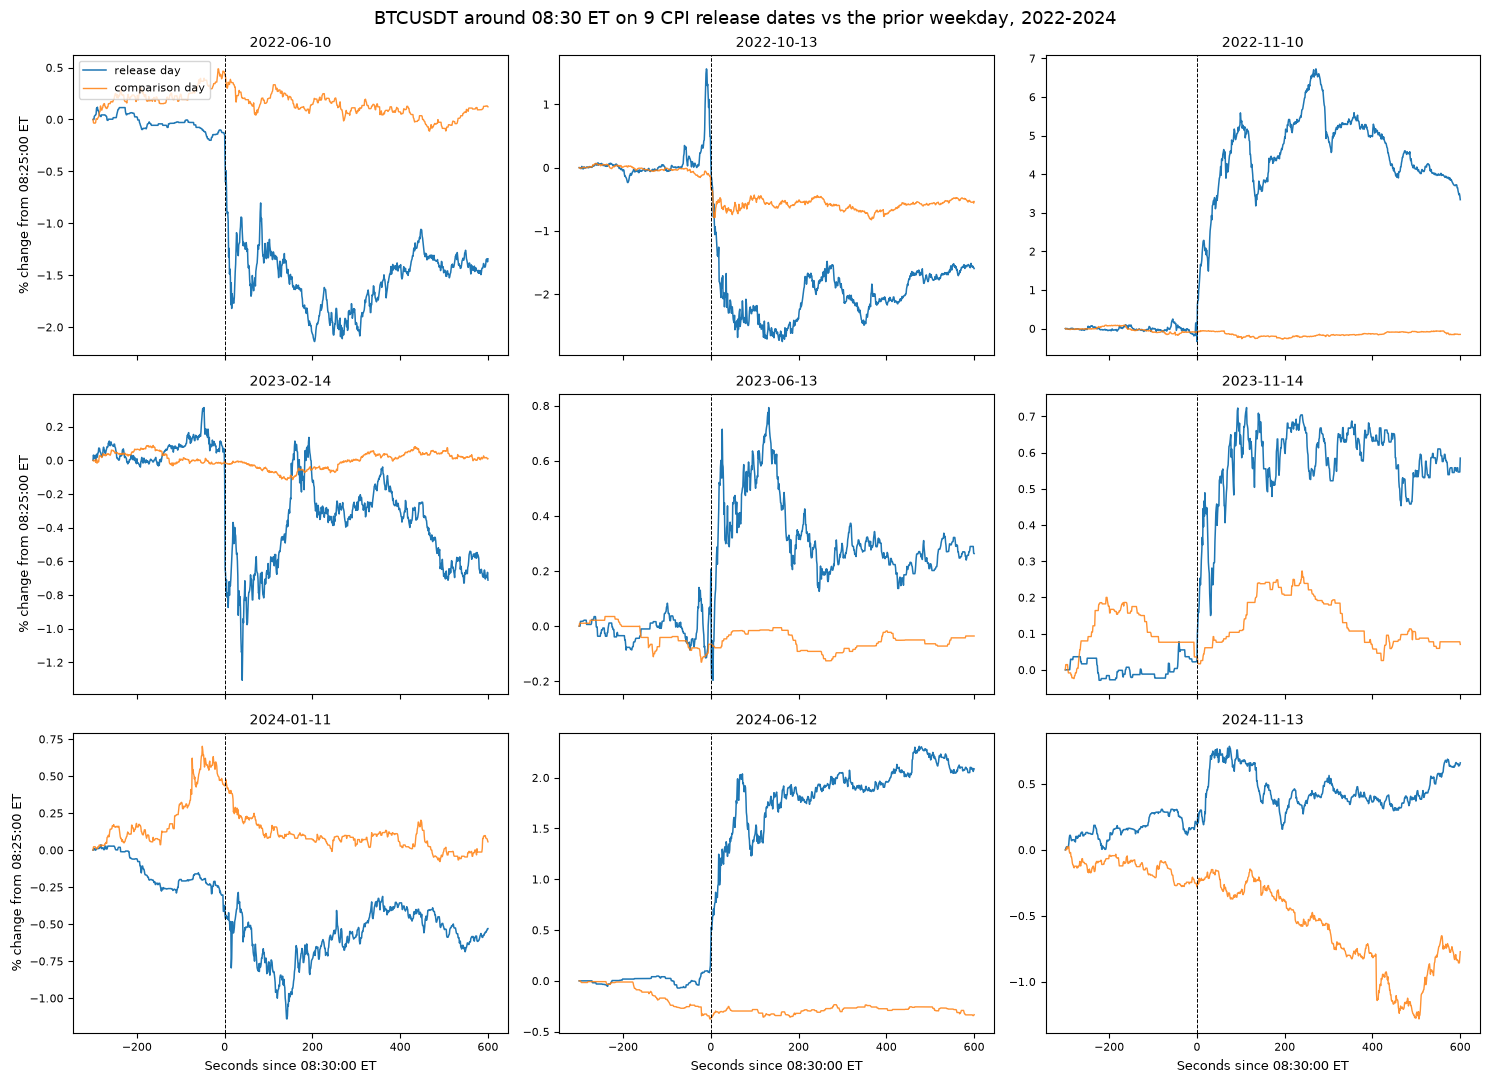

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=True)
for ax, (release_date, comparison_date) in zip(axes.flat, RELEASES, strict=True):
    rel = windowed_series(release_date)
    cmp_ = windowed_series(comparison_date)
    ax.plot(
        rel["seconds_since_event"],
        pct_from_window_start(rel),
        color="C0",
        linewidth=1.1,
        label="release day",
    )
    ax.plot(
        cmp_["seconds_since_event"],
        pct_from_window_start(cmp_),
        color="C1",
        linewidth=1.0,
        alpha=0.85,
        label="comparison day",
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=0.7)
    ax.set_title(release_date, fontsize=10)
    ax.tick_params(labelsize=8)

axes[0, 0].legend(fontsize=8, loc="upper left")
for ax in axes[-1, :]:
    ax.set_xlabel("Seconds since 08:30:00 ET", fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel("% change from 08:25:00 ET", fontsize=9)
title = f"{SYMBOL} around 08:30 ET on 9 CPI release dates vs the prior weekday, 2022-2024"
fig.suptitle(title, fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "spikeGrid.png", dpi=150)
plt.show()

## Observation

In 9/9 releases tested, the largest single-second move in the 30 seconds after 08:30:00 ET is
larger on the release day than on the comparison day at the same clock time. Ratio of release-day
jump to comparison-day jump: 3.6x (2024-11-13) to 64x (2023-02-14), median 5.6x. See `jump_table`
above. In every panel of the grid, the release-day line has a visible kink at the dashed line; the
comparison line does not.

Direction is not consistent: up on some releases, down on others, matching whether the print was
a hot or cool surprise relative to expectations. Lag is not measured here; that needs the
estimand, which is not chosen yet.

There is a visible jump, and it holds across all 9 dates tested.